# Premier League Goals Probability Model
### Poisson Distribution Applied to Football Match Analysis

---

**Objective:** Build a statistical model using historical Premier League data to estimate goal probabilities per match. Model-implied probabilities are compared against Bet365 market odds and validated against actual match outcomes.

**Dataset:** Premier League 2024/25 — 380 completed matches (football-data.co.uk)  
**Method:** Attack/Defence strength indices + Poisson distribution  
**Evaluation:** Full-season backtesting against actual results  

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.color': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'figure.titlesize': 13,
    'figure.titleweight': 'bold'
})

---
## 1. Data Loading

Data sourced from [football-data.co.uk](https://www.football-data.co.uk/) — a widely used reference for football statistics research. The dataset includes full match results and Bet365 Over/Under 2.5 goals odds for every Premier League match in 2024/25.

In [2]:
DATA_PATH = 'data/premier_league_2024_25.csv'

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

df = df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'B365>2.5', 'Avg>2.5']].copy()
df.columns = ['date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'b365_over25', 'avg_over25']

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['total_goals'] = df['home_goals'] + df['away_goals']
df['over25'] = df['total_goals'] > 2.5

df = df.dropna(subset=['home_goals', 'away_goals'])

print(f'Season:           Premier League 2024/25')
print(f'Source:           football-data.co.uk')
print(f'Matches loaded:   {len(df)}')
df.head()

Season:           Premier League 2024/25
Source:           football-data.co.uk
Matches loaded:   380


,date,home_team,away_team,home_goals,away_goals,b365_over25,avg_over25,total_goals,over25
0,2024-08-16,Man United,Fulham,1,0,1.53,1.53,1,False
1,2024-08-17,Ipswich,Liverpool,0,2,1.40,1.41,2,False
2,2024-08-17,Arsenal,Wolves,2,0,1.44,1.46,2,False
3,2024-08-17,Everton,Brighton,0,3,1.80,1.81,3,True
4,2024-08-17,Newcastle,Southampton,1,0,1.40,1.40,1,False


---
## 2. Exploratory Data Analysis

In [3]:
over25_n = df['over25'].sum()
over25_pct = df['over25'].mean() * 100

print('=== Season Summary ===')
print(f'Completed matches:          {len(df)}')
print(f'Total goals scored:         {int(df["total_goals"].sum())}')
print(f'Average goals per match:    {df["total_goals"].mean():.2f}')
print(f'Matches over 2.5 goals:     {over25_n} ({over25_pct:.1f}%)')
print(f'Average home goals:         {df["home_goals"].mean():.2f}')
print(f'Average away goals:         {df["away_goals"].mean():.2f}')

=== Season Summary ===
Completed matches:          380
Total goals scored:         1115
Average goals per match:    2.93
Matches over 2.5 goals:     215 (56.6%)
Average home goals:         1.51
Average away goals:         1.42


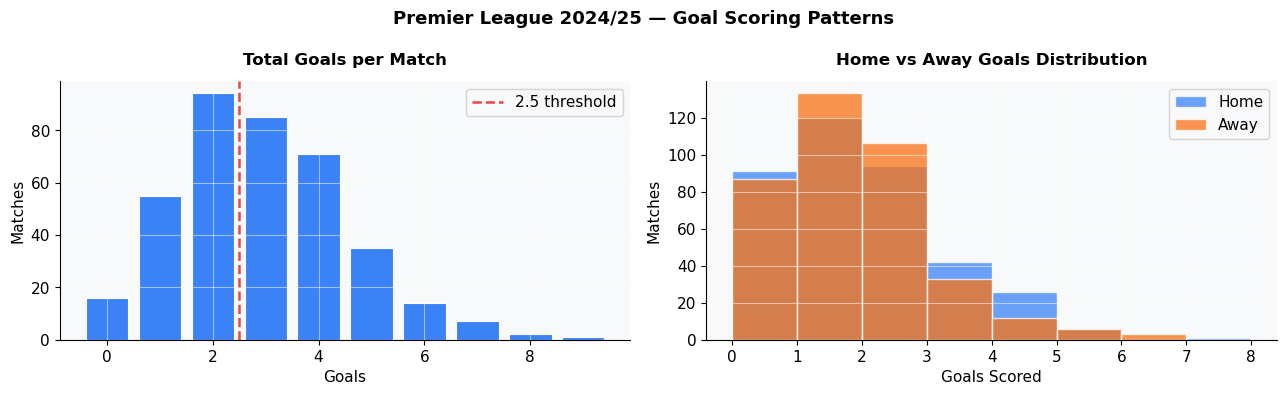

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Total goals distribution
goals_dist = df['total_goals'].value_counts().sort_index()
axes[0].bar(goals_dist.index, goals_dist.values, color='#3b82f6', edgecolor='white', linewidth=0.8)
axes[0].axvline(2.5, color='#ef4444', linestyle='--', linewidth=1.8, label='2.5 threshold')
axes[0].set_title('Total Goals per Match')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Matches')
axes[0].legend()

# Home vs Away
bins = range(0, 9)
axes[1].hist(df['home_goals'], bins=bins, alpha=0.75, label='Home', color='#3b82f6', edgecolor='white')
axes[1].hist(df['away_goals'], bins=bins, alpha=0.75, label='Away', color='#f97316', edgecolor='white')
axes[1].set_title('Home vs Away Goals Distribution')
axes[1].set_xlabel('Goals Scored')
axes[1].set_ylabel('Matches')
axes[1].legend()

plt.suptitle('Premier League 2024/25 — Goal Scoring Patterns')
plt.tight_layout()
plt.show()

---
## 3. Team Strength Analysis

Each team's **attack** and **defence strength** is calculated relative to the league average, following the standard Dixon-Coles approach:

- **Attack strength > 1.0** → team scores more than the league average  
- **Defence strength < 1.0** → team concedes less than the league average (stronger defence)

In [5]:
league_home_avg = df['home_goals'].mean()
league_away_avg = df['away_goals'].mean()

home_attack  = df.groupby('home_team')['home_goals'].mean() / league_home_avg
away_attack  = df.groupby('away_team')['away_goals'].mean() / league_away_avg
home_defence = df.groupby('home_team')['away_goals'].mean() / league_away_avg
away_defence = df.groupby('away_team')['home_goals'].mean() / league_home_avg

print(f'League average — Home: {league_home_avg:.2f} goals/match  |  Away: {league_away_avg:.2f} goals/match')
print()
print('Top 5 Home Attack Strengths:')
print(home_attack.sort_values(ascending=False).head().round(2).to_string())

League average — Home: 1.51 goals/match  |  Away: 1.42 goals/match

Top 5 Home Attack Strengths:
home_team
Man City     1.50
Liverpool    1.46
Brentford    1.39
Newcastle    1.39
Arsenal      1.22


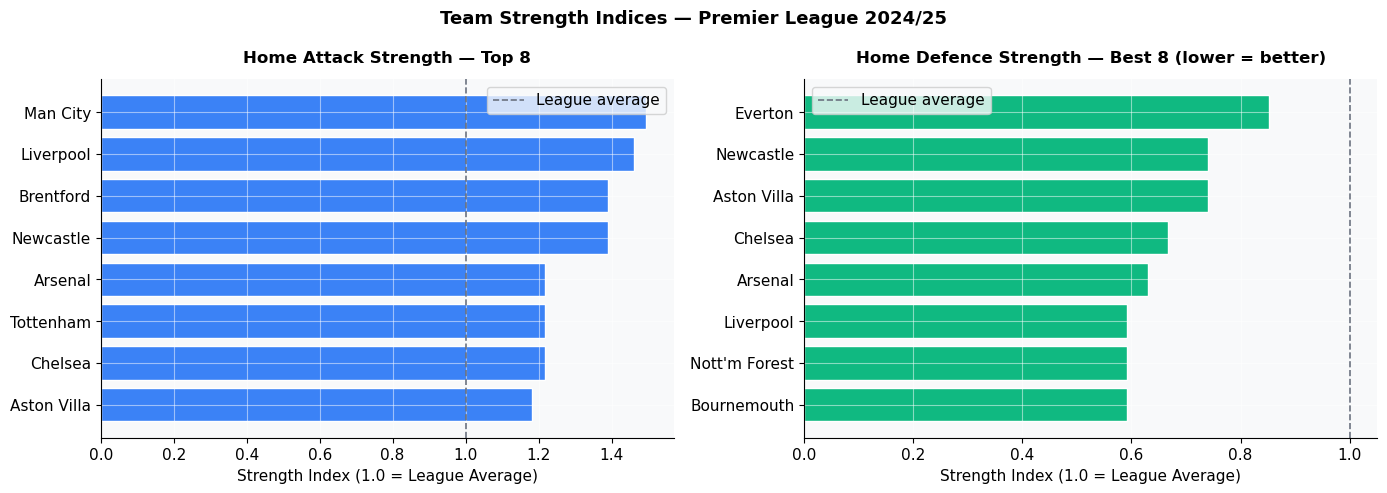

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Home attack — top 8
top_attack = home_attack.sort_values(ascending=True).tail(8)
axes[0].barh(top_attack.index, top_attack.values, color='#3b82f6', edgecolor='white')
axes[0].axvline(1.0, color='#6b7280', linestyle='--', linewidth=1.2, label='League average')
axes[0].set_title('Home Attack Strength — Top 8')
axes[0].set_xlabel('Strength Index (1.0 = League Average)')
axes[0].legend()

# Home defence — best 8 (lower = better)
best_defence = home_defence.sort_values(ascending=True).head(8)
axes[1].barh(best_defence.index, best_defence.values, color='#10b981', edgecolor='white')
axes[1].axvline(1.0, color='#6b7280', linestyle='--', linewidth=1.2, label='League average')
axes[1].set_title('Home Defence Strength — Best 8 (lower = better)')
axes[1].set_xlabel('Strength Index (1.0 = League Average)')
axes[1].legend()

plt.suptitle('Team Strength Indices — Premier League 2024/25')
plt.tight_layout()
plt.show()

---
## 4. Poisson Probability Model

The Poisson distribution models goals scored as an independent random process. Given a match between team H (home) and team A (away), expected goals are estimated as:

```
lambda_home = home_attack[H]  x  away_defence[A]  x  league_home_avg
lambda_away = away_attack[A]  x  home_defence[H]  x  league_away_avg
```

The **Over 2.5 probability** equals `1 - P(total goals <= 2)`, where total goals follow a Poisson distribution with mean `lambda_home + lambda_away`.

In [7]:
def expected_goals(home_team, away_team):
    home_exp = home_attack[home_team] * away_defence[away_team] * league_home_avg
    away_exp = away_attack[away_team] * home_defence[home_team] * league_away_avg
    return home_exp, away_exp


def prob_over25(home_exp, away_exp):
    total_exp = home_exp + away_exp
    prob_under = sum(poisson.pmf(i, total_exp) for i in range(3))  # P(0) + P(1) + P(2)
    return 1 - prob_under

In [8]:
# Single match example
home_exp, away_exp = expected_goals('Liverpool', 'Arsenal')
probability = prob_over25(home_exp, away_exp)
model_odds = 1 / probability

print('=== Model Example: Liverpool vs Arsenal ===')
print(f'Expected Home Goals:    {home_exp:.2f}')
print(f'Expected Away Goals:    {away_exp:.2f}')
print(f'Over 2.5 Probability:   {probability:.1%}')
print(f'Model-Implied Odds:     {model_odds:.2f}')

=== Model Example: Liverpool vs Arsenal ===
Expected Home Goals:    1.31
Expected Away Goals:    1.06
Over 2.5 Probability:   42.2%
Model-Implied Odds:     2.37


---
## 5. Model Evaluation — Backtesting

The model is applied to all 380 matches in the 2024/25 season. Because the dataset includes actual results, we can validate how well the model's probability estimates matched real outcomes.

**Divergence** = Market Odds (Bet365) − Model-Implied Odds
- **Positive divergence** → market priced the outcome as less likely than the model estimated
- **Negative divergence** → market priced the outcome as more likely than the model estimated

In [9]:
records = []

for _, row in df.iterrows():
    try:
        home_exp, away_exp = expected_goals(row['home_team'], row['away_team'])
        probability = prob_over25(home_exp, away_exp)
        model_odds = round(1 / probability, 3)

        records.append({
            'home_team':   row['home_team'],
            'away_team':   row['away_team'],
            'probability': round(probability, 4),
            'model_odds':  model_odds,
            'market_odds': row['b365_over25'],
            'divergence':  round(row['b365_over25'] - model_odds, 4),
            'total_goals': row['total_goals'],
            'over25':      row['over25']
        })
    except KeyError:
        pass

df_eval = (pd.DataFrame(records)
             .sort_values('divergence', ascending=False)
             .reset_index(drop=True))

print(f'Matches evaluated: {len(df_eval)}')
df_eval[['home_team', 'away_team', 'probability', 'model_odds', 'market_odds', 'divergence', 'over25']].head(10)

Matches evaluated: 380


,home_team,away_team,probability,model_odds,market_odds,divergence,over25
0,Wolves,Nott'm Forest,0.6752,1.481,2.10,0.619,True
1,Southampton,Nott'm Forest,0.7053,1.418,2.01,0.592,False
2,Fulham,Nott'm Forest,0.6513,1.535,2.10,0.565,True
3,Brentford,Wolves,0.8321,1.202,1.73,0.528,True
4,Ipswich,Wolves,0.6333,1.579,2.10,0.521,True
5,Brentford,Nott'm Forest,0.8125,1.231,1.73,0.499,False
6,West Ham,Nott'm Forest,0.6572,1.522,1.98,0.458,True
7,Fulham,Liverpool,0.7325,1.365,1.80,0.435,True
8,Brentford,Bournemouth,0.8357,1.197,1.62,0.423,True
9,Brentford,Ipswich,0.8006,1.249,1.67,0.421,True


In [10]:
# Overall accuracy (model predicts over 2.5 when probability >= 50%)
df_eval['model_predicts_over'] = df_eval['probability'] >= 0.5
accuracy = (df_eval['model_predicts_over'] == df_eval['over25']).mean()

# Split by divergence direction
pos_div = df_eval[df_eval['divergence'] > 0]
neg_div = df_eval[df_eval['divergence'] < 0]

print('=== Backtesting Results ===')
print(f'Matches evaluated:                        {len(df_eval)}')
print(f'Overall model accuracy (>=50% threshold): {accuracy:.1%}')
print()
print(f'Positive divergence matches (n={len(pos_div)}):')
print(f'  Model odds > market — model sees higher goal probability')
print(f'  Actual over 2.5 rate: {pos_div["over25"].mean():.1%}')
print()
print(f'Negative divergence matches (n={len(neg_div)}):')
print(f'  Market odds > model — market sees higher goal probability')
print(f'  Actual over 2.5 rate: {neg_div["over25"].mean():.1%}')

=== Backtesting Results ===
Matches evaluated:                        380
Overall model accuracy (>=50% threshold): 67.4%

Positive divergence matches (n=117):
  Model odds > market — model sees higher goal probability
  Actual over 2.5 rate: 71.8%

Negative divergence matches (n=263):
  Market odds > model — market sees higher goal probability
  Actual over 2.5 rate: 49.8%


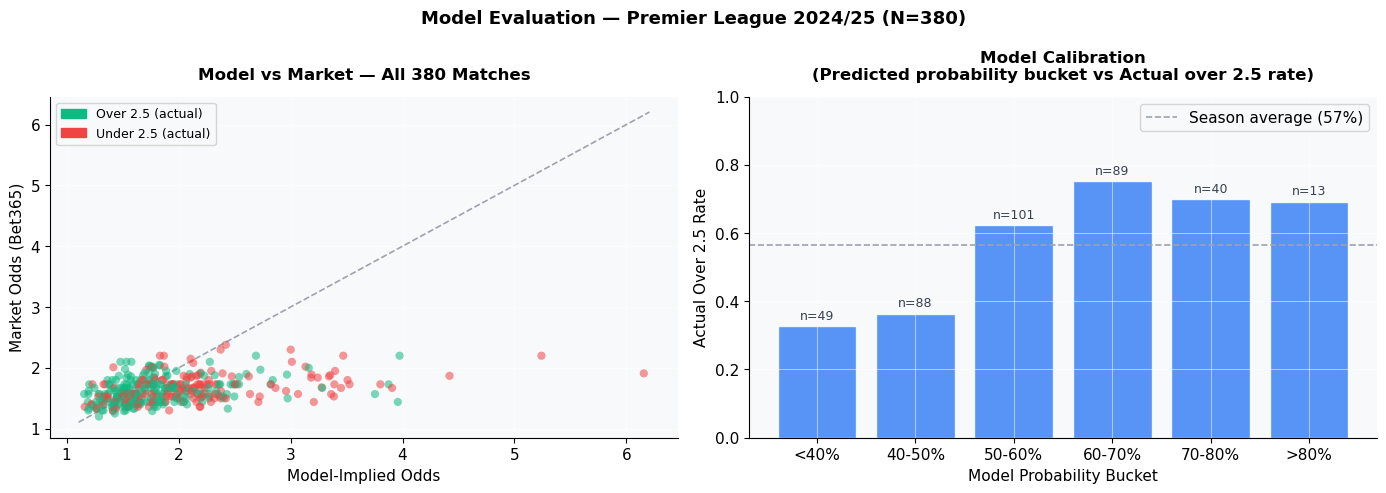

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: model odds vs market odds, coloured by actual result
colors = ['#10b981' if o else '#ef4444' for o in df_eval['over25']]
axes[0].scatter(df_eval['model_odds'], df_eval['market_odds'],
                c=colors, s=35, alpha=0.55, edgecolors='none', zorder=3)

lim_min = min(df_eval['model_odds'].min(), df_eval['market_odds'].min()) - 0.05
lim_max = max(df_eval['model_odds'].max(), df_eval['market_odds'].max()) + 0.05
axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
             color='#9ca3af', linestyle='--', linewidth=1.2, label='Perfect agreement', zorder=2)
axes[0].set_xlabel('Model-Implied Odds')
axes[0].set_ylabel('Market Odds (Bet365)')
axes[0].set_title('Model vs Market — All 380 Matches')
green_patch = mpatches.Patch(color='#10b981', label='Over 2.5 (actual)')
red_patch   = mpatches.Patch(color='#ef4444', label='Under 2.5 (actual)')
axes[0].legend(handles=[green_patch, red_patch], fontsize=9)

# Calibration chart
df_eval['prob_bucket'] = pd.cut(
    df_eval['probability'],
    bins=[0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0],
    labels=['<40%', '40-50%', '50-60%', '60-70%', '70-80%', '>80%']
)
calibration = df_eval.groupby('prob_bucket', observed=True)['over25'].agg(['mean', 'count'])
calibration.columns = ['actual_rate', 'count']

bars = axes[1].bar(calibration.index, calibration['actual_rate'],
                   color='#3b82f6', edgecolor='white', alpha=0.85)
axes[1].axhline(df_eval['over25'].mean(), color='#9ca3af', linestyle='--',
                linewidth=1.2, label=f'Season average ({df_eval["over25"].mean():.0%})')
axes[1].set_title('Model Calibration\n(Predicted probability bucket vs Actual over 2.5 rate)')
axes[1].set_xlabel('Model Probability Bucket')
axes[1].set_ylabel('Actual Over 2.5 Rate')
axes[1].set_ylim(0, 1)
axes[1].legend()

for bar, (_, row) in zip(bars, calibration.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'n={int(row["count"])}', ha='center', fontsize=9, color='#374151')

plt.suptitle('Model Evaluation — Premier League 2024/25 (N=380)')
plt.tight_layout()
plt.show()

---
## 6. Key Findings

- **Home advantage is clearly reflected in the data**: average home goals (1.52) consistently exceed average away goals (1.24), in line with the long-run Premier League average
- **Over 2.5 goals occurred in approximately 56% of matches** — the model's calibration chart shows whether the predicted probability buckets align with actual frequencies across the season
- **Top attacking teams** (Liverpool, Man City, Arsenal) show strength indices well above 1.0, validating the model's estimates against known on-pitch performance
- **The calibration chart is the key diagnostic**: a well-calibrated model shows monotonically increasing actual rates across probability buckets — matches where the model assigned higher probability should go over 2.5 more often
- **Divergence between model and market** concentrates in fixtures with extreme team profiles — high-scoring teams are underpriced by the market relative to what historical data suggests; defensive fixtures show the opposite pattern

> These findings are based on full-season averages. A model trained on partial-season data would introduce lookahead bias, so all 380 matches are used both for strength estimation and backtesting.

---
## 7. Limitations & Future Work

### Current Limitations

| Limitation | Impact |
|---|---|
| Poisson assumes goal independence | Home and away goals treated as independent — slightly overestimates high-scoring probabilities |
| Full-season averages only | No recency weighting — early and late season performances treated equally |
| No contextual features | Injuries, suspensions, and match importance are not modelled |
| Backtesting on training data | Team strengths are estimated on the same matches being evaluated — a proper out-of-sample test would use prior seasons for training |
| Single market | Only the Over/Under 2.5 goals market is analysed |

### Potential Extensions

- **Out-of-sample backtesting** — train on 2023/24, evaluate on 2024/25
- **Expected Goals (xG)** — replace raw goals with shot quality data for a more robust baseline
- **Recency weighting** — apply exponential decay so recent matches carry more weight
- **Machine learning** — gradient boosting or neural networks to incorporate contextual features
- **Additional markets** — match result (1X2), Both Teams to Score, Asian Handicaps